# Proyecto Ciencia de Datos
Limpieza y Transformación de Datos

In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [13]:
# Cargamos dataset
df = pd.read_csv('/content/hourlySteps_merged.csv')
df.head()

,Id,ActivityHour,StepTotal
0,1503960366,3/12/2016 12:00:00 AM,0
1,1503960366,3/12/2016 1:00:00 AM,0
2,1503960366,3/12/2016 2:00:00 AM,0
3,1503960366,3/12/2016 3:00:00 AM,0
4,1503960366,3/12/2016 4:00:00 AM,0


# Exploración Inicial

In [14]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24084 entries, 0 to 24083
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            24084 non-null  int64 
 1   ActivityHour  24084 non-null  object
 2   StepTotal     24084 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 564.6+ KB


,0
Id,0
ActivityHour,0
StepTotal,0


In [15]:
print("Duplicados:")
print(df.duplicated().sum())

Duplicados:
0


Podemos observar que el dataset está completamente limpio, por lo que tomaremos la desición de ensuciarlo nostros mismos.

# Verificar carga de datos

In [16]:
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (24084, 3)


,Id,ActivityHour,StepTotal
0,1503960366,3/12/2016 12:00:00 AM,0
1,1503960366,3/12/2016 1:00:00 AM,0
2,1503960366,3/12/2016 2:00:00 AM,0
3,1503960366,3/12/2016 3:00:00 AM,0
4,1503960366,3/12/2016 4:00:00 AM,0


Verificamos las dimensiones que tiene el dataset para poder ensuciarlo y ver que si incrementa.

In [17]:
import pandas as pd
import numpy as np

# Cargar dataset original
df = pd.read_csv('/content/hourlySteps_merged.csv')

# -----------------------------
# 1. DUPLICAR FILAS
# -----------------------------
df_duplicado = df.sample(frac=0.2, random_state=42)  # duplica 20%
df_sucio = pd.concat([df, df_duplicado], ignore_index=True)

print("Filas originales:", df.shape[0])
print("Filas después de duplicar:", df_sucio.shape[0])

# -----------------------------
# 2. AGREGAR NULOS
# -----------------------------
# porcentaje de nulos
porcentaje_nulos = 0.05  # 5%

for col in df_sucio.columns:
    df_sucio.loc[
        df_sucio.sample(frac=porcentaje_nulos).index, col
    ] = np.nan

# -----------------------------
# 3. GUARDAR DATASET SUCIO
# -----------------------------
df_sucio.to_csv('/content/hourlySteps_sucio.csv', index=False)

print("Dataset sucio creado ✅")

Filas originales: 24084
Filas después de duplicar: 28901
Dataset sucio creado ✅


In [18]:
print("Nulos por columna:")
print(df_sucio.isnull().sum())

print("\nDuplicados:")
print(df_sucio.duplicated().sum())

Nulos por columna:
Id              1445
ActivityHour    1445
StepTotal       1445
dtype: int64

Duplicados:
4417


Verificamos que nulos y duplicados incrementen en una buena cantidad.

In [19]:
#Creamos dataset sucio para poder trabajar con este y limpiarlo de manera exitosa
df = pd.read_csv('/content/hourlySteps_sucio.csv')

# CARGAR DATASET SUCIO

In [20]:
df = pd.read_csv('/content/hourlySteps_sucio.csv')

print("Dimensiones iniciales:", df.shape)
df.head()

Dimensiones iniciales: (28901, 3)


,Id,ActivityHour,StepTotal
0,1.503960e+09,3/12/2016 12:00:00 AM,0.0
1,1.503960e+09,3/12/2016 1:00:00 AM,0.0
2,1.503960e+09,3/12/2016 2:00:00 AM,0.0
3,1.503960e+09,3/12/2016 3:00:00 AM,0.0
4,1.503960e+09,3/12/2016 4:00:00 AM,0.0


Cargamos el nuevo dataset, indicando las nuevas dimensiones de este (que son 28901, 3; y antes 24084, 3).

# ANTES (DIAGNÓSTICO COMPLETO)

In [21]:
print("NULOS:")
print(df.isnull().sum())

print("\nDUPLICADOS:")
print(df.duplicated().sum())

print("\nTIPOS DE DATOS:")
print(df.dtypes)

NULOS:
Id              1445
ActivityHour    1445
StepTotal       1445
dtype: int64

DUPLICADOS:
4417

TIPOS DE DATOS:
Id              float64
ActivityHour     object
StepTotal       float64
dtype: object


Indicamos los nulos y duplicados existentes del nuevo dataset.

# LIMPIEZA DE DUPLICADOS

In [22]:
df = df.drop_duplicates()

print("Duplicados después:", df.duplicated().sum())

Duplicados después: 0


Limpiamos duplicados con la acción "Drop".

# LIMPIEZA DE NULOS

In [23]:
df = df.dropna()

print("Nulos después:")
print(df.isnull().sum())

Nulos después:
Id              0
ActivityHour    0
StepTotal       0
dtype: int64


Hacemos lo mismo con los nulos, también usando "Drop".

# VERIFICACIÓN POST LIMPIEZA

In [24]:
print("Dimensiones después de limpieza:", df.shape)

Dimensiones después de limpieza: (21267, 3)


Verificamos las dimensiones del dataset, viendo que disminuyó gracias a la eliminación de nulos y duplicados.

# FEATURE ENGINEERING

In [25]:
df['ActivityHour'] = pd.to_datetime(df['ActivityHour'])

df['Hora'] = df['ActivityHour'].dt.hour
df['Dia'] = df['ActivityHour'].dt.day_name()
df['FinDeSemana'] = df['Dia'].isin(['Saturday', 'Sunday']).astype(int)

df.head()

/tmp/ipykernel_896/1259788934.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ActivityHour'] = pd.to_datetime(df['ActivityHour'])


,Id,ActivityHour,StepTotal,Hora,Dia,FinDeSemana
0,1.503960e+09,2016-03-12 00:00:00,0.0,0,Saturday,1
1,1.503960e+09,2016-03-12 01:00:00,0.0,1,Saturday,1
2,1.503960e+09,2016-03-12 02:00:00,0.0,2,Saturday,1
3,1.503960e+09,2016-03-12 03:00:00,0.0,3,Saturday,1
4,1.503960e+09,2016-03-12 04:00:00,0.0,4,Saturday,1


**Feature Engineering (Ingeniería de Características)**

El *feature engineering* es el proceso de transformar y crear nuevas variables (features) a partir de los datos originales para mejorar el análisis o el rendimiento de modelos de machine learning.

En este caso, a partir de la columna `ActivityHour` (que contiene fecha y hora), se generan nuevas variables más informativas:

* Se convierte `ActivityHour` a formato datetime para poder manipularla correctamente.
* Se extrae la **hora del día** (`Hora`), lo que permite analizar patrones según el momento del día.
* Se obtiene el **día de la semana** (`Dia`), útil para identificar comportamientos distintos entre días.
* Se crea una variable binaria (`FinDeSemana`) que indica si el registro corresponde a fin de semana (1) o no (0).

Estas transformaciones simplifican la información original y permiten que los modelos o análisis detecten patrones más fácilmente.


# ANTES vs DESPUÉS

In [26]:
print("ANTES (StepTotal):")
print(df['StepTotal'].describe())

ANTES (StepTotal):
count    21267.000000
mean       286.101942
std        661.909335
min          0.000000
25%          0.000000
50%         10.000000
75%        292.000000
max      10565.000000
Name: StepTotal, dtype: float64


**Análisis previo de la variable `StepTotal`**

Antes de aplicar cualquier transformación o pipeline, es importante explorar los datos originales. En este caso, se utiliza `describe()` sobre la columna `StepTotal` para obtener un resumen estadístico.

Este resumen incluye:

* **count**: cantidad de registros disponibles
* **mean**: promedio de pasos
* **std**: desviación estándar (qué tan dispersos están los datos)
* **min** y **max**: valores mínimo y máximo
* **25%**, **50% (mediana)** y **75%**: percentiles que muestran la distribución de los datos

Este análisis permite entender la distribución inicial de los pasos, detectar posibles valores atípicos (outliers) y tener una referencia clara del estado de los datos antes de aplicar el pipeline de procesamiento.


# PIPELINE

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

numericas = df[['StepTotal']]

pipeline = Pipeline([
    ('imputador', SimpleImputer(strategy='mean')),
    ('escalador', StandardScaler())
])

df['StepTotal_scaled'] = pipeline.fit_transform(numericas)

**Pipeline de preprocesamiento para `StepTotal`**

En este bloque se construye un *pipeline* utilizando herramientas de `sklearn` para automatizar el preprocesamiento de la variable `StepTotal`.

Primero, se selecciona la columna numérica que se desea transformar (`StepTotal`). Luego, se define un pipeline con dos pasos:

* **Imputación de valores faltantes**: se utiliza `SimpleImputer` con estrategia `"mean"` para reemplazar valores nulos por el promedio de la columna. Esto evita problemas en el análisis o en modelos que no aceptan datos faltantes.
* **Escalado de datos**: se aplica `StandardScaler`, que estandariza los valores transformándolos para que tengan media 0 y desviación estándar 1. Esto es importante para muchos modelos de machine learning que son sensibles a la escala de los datos.

Finalmente, el pipeline se ajusta y transforma los datos con `fit_transform`, y el resultado se guarda en una nueva columna llamada `StepTotal_scaled`.

Este enfoque permite aplicar múltiples transformaciones de forma ordenada, reproducible y eficiente.


# DESPUÉS

In [28]:
print("DESPUÉS (StepTotal escalado):")
print(df['StepTotal_scaled'].describe())

DESPUÉS (StepTotal escalado):
count    2.126700e+04
mean    -9.354961e-18
std      1.000024e+00
min     -4.322475e-01
25%     -4.322475e-01
50%     -4.171394e-01
75%      8.910883e-03
max      1.552953e+01
Name: StepTotal_scaled, dtype: float64


**Análisis posterior de la variable `StepTotal_scaled`**

Después de aplicar el pipeline de preprocesamiento, se vuelve a utilizar `describe()` para observar cómo cambiaron los datos tras la transformación.

En este caso, la columna `StepTotal_scaled` ha sido estandarizada, por lo que:

* La **media (mean)** será aproximadamente 0
* La **desviación estándar (std)** será aproximadamente 1
* Los valores estarán centrados alrededor de 0, incluyendo valores negativos y positivos

Este análisis permite verificar que el escalado se realizó correctamente y comparar el estado de los datos antes y después del procesamiento. Además, confirma que la variable ahora está en una escala adecuada para modelos de machine learning.


# VERIFICACIÓN FINAL

In [29]:
print("Nulos finales:")
print(df.isnull().sum())

print("\nDuplicados finales:")
print(df.duplicated().sum())

Nulos finales:
Id                  0
ActivityHour        0
StepTotal           0
Hora                0
Dia                 0
FinDeSemana         0
StepTotal_scaled    0
dtype: int64

Duplicados finales:
0


**Verificación final de calidad de datos**

En este paso se realiza una revisión final del dataset para asegurar su calidad después del preprocesamiento.

* **Valores nulos (`isnull().sum()`)**: se cuenta la cantidad de datos faltantes por columna. Esto permite confirmar que el proceso de imputación fue exitoso y que no quedan valores nulos que puedan afectar el análisis o los modelos.

* **Registros duplicados (`duplicated().sum()`)**: se calcula el número de filas duplicadas en el dataset. Esto es importante porque los duplicados pueden sesgar los resultados y afectar el rendimiento de los modelos.

Esta verificación final asegura que los datos están limpios, completos y listos para ser utilizados en análisis o entrenamiento de modelos de machine learning.


# Gráfico de outliers

<Axes: >

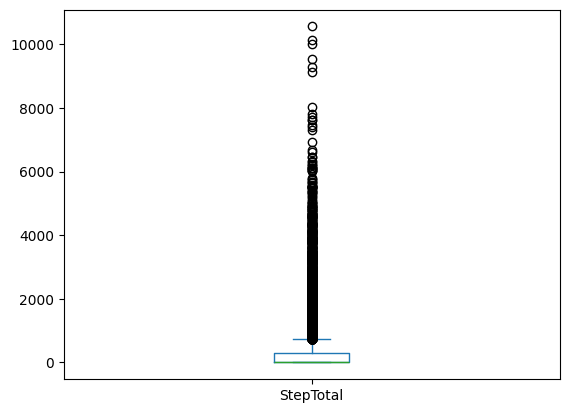

In [30]:
df['StepTotal'].plot.box()

Se detectaron outliers mediante el método IQR, ya que permite identificar valores extremos de forma robusta. Dependiendo del contexto, estos pueden ser eliminados o analizados por separado.

El gráfico nos muestra que:


*   La mayoría de los días tienen un número bajo de pasos.
*   Existen numerosos días con actividad excpecionalmente alta.


*   La distribución está sesgada a la derecha
*   El método IQR es adecuado para identificar esos valores extremos.





# Gráfico pasos por hora



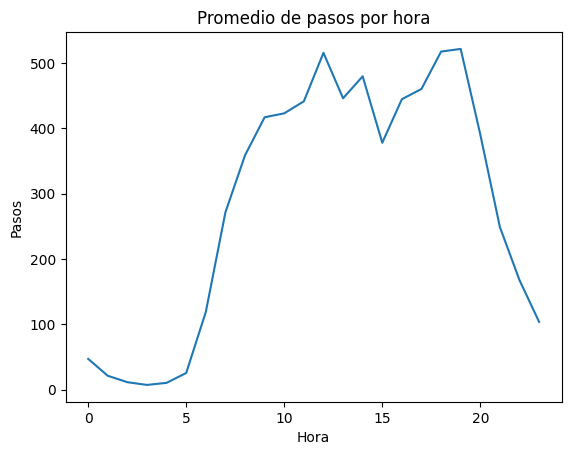

In [ ]:
df.groupby('Hora')['StepTotal'].mean().plot(kind='line')

plt.title('Promedio de pasos por hora')
plt.xlabel('Hora')
plt.ylabel('Pasos')
plt.show()

Este gráfico muestra cómo varía la actividad física a lo largo del día. Permite identificar en qué horas se concentra la mayor cantidad de pasos.

# EXPORTAR DATASET LIMPIO

In [31]:
df.to_csv('/content/hourlySteps_clean.csv', index=False)

print("Dataset limpio guardado ✅")

Dataset limpio guardado ✅
